# 打造客製化看盤軟體


In [ ]:
import sys
import os
import pandas as pd
import sqlite3

# 添加上一層目錄到 sys.path
sys.path.insert(0, os.path.join(os.getcwd(), '..'))


# connect to sql
conn = sqlite3.connect(os.path.join('..', 'data', "data.db"))

# read data from sql
df = pd.read_sql(
    'select stock_id, date, 開盤價, 收盤價, 最高價, 最低價, 成交股數 from price where stock_id="0050"',
    conn,
    index_col=['date'],
    parse_dates=['date'],  # 將 date 欄位, 字串轉日期格式
)

# rename the columns of dataframe
df.rename(
    columns={
        '收盤價': 'close',
        '開盤價': 'open',
        '最高價': 'high',
        '最低價': 'low',
        '成交股數': 'volume',
    },
    inplace=True,
)

df.head()

,stock_id,open,close,high,low,volume
date,,,,,,
2018-03-26,0050,81.85,82.2,82.2,81.6,4369122


### install TA-Lib

https://github.com/mrjbq7/ta-lib


<Axes: xlabel='date'>

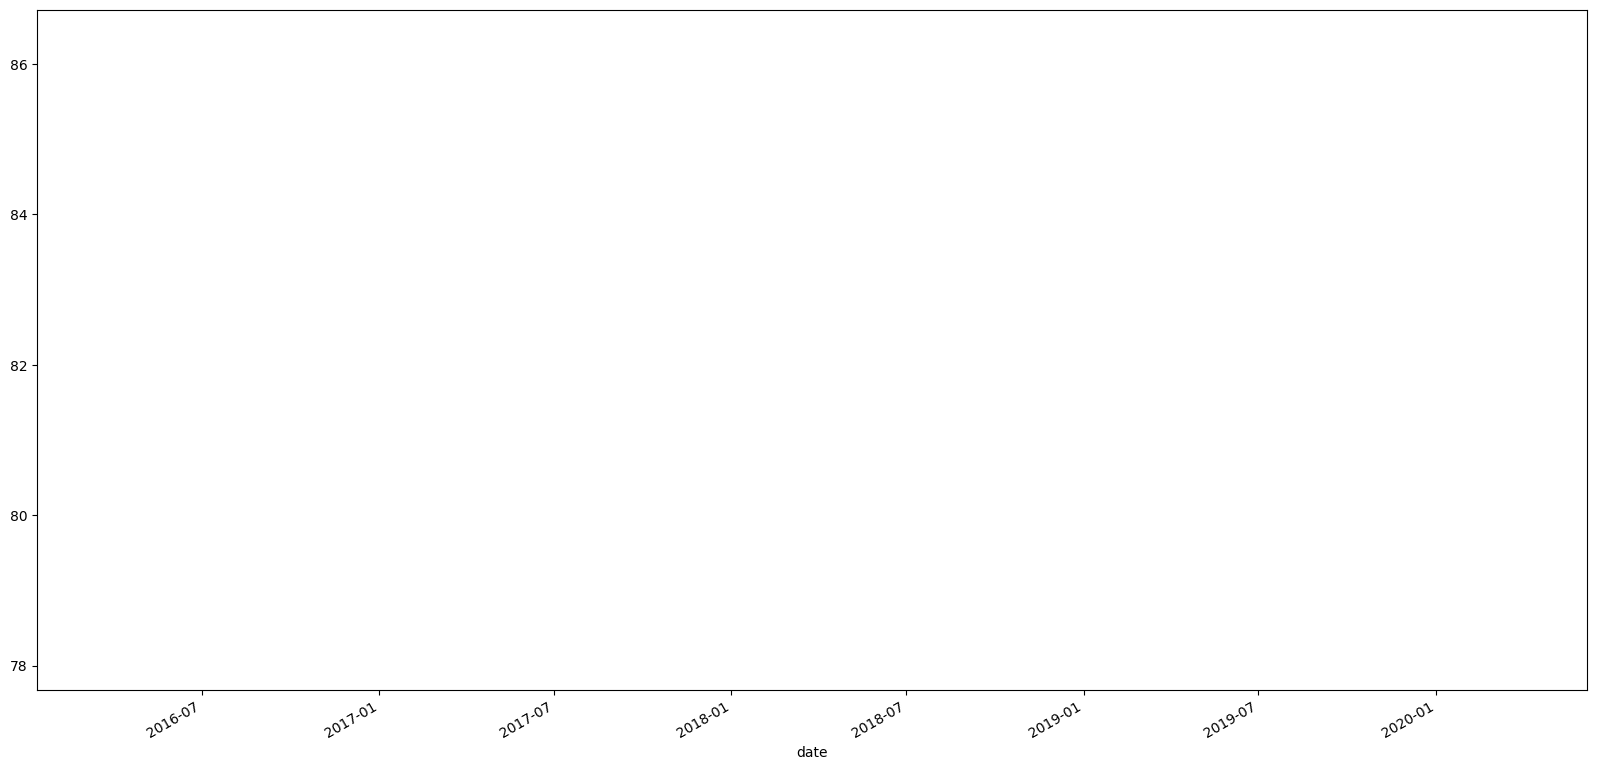

In [5]:
%matplotlib inline
import matplotlib.pyplot as plt

## change the size of plot
plt.rcParams["figure.figsize"] = (20,10)

## plot close price
df['close'].plot()

In [ ]:
import sys

sys.version  # 查詢 py 版本

'3.14.5 (main, May 10 2026, 20:29:46) [MSC v.1944 64 bit (AMD64)]'

<Axes: xlabel='date'>

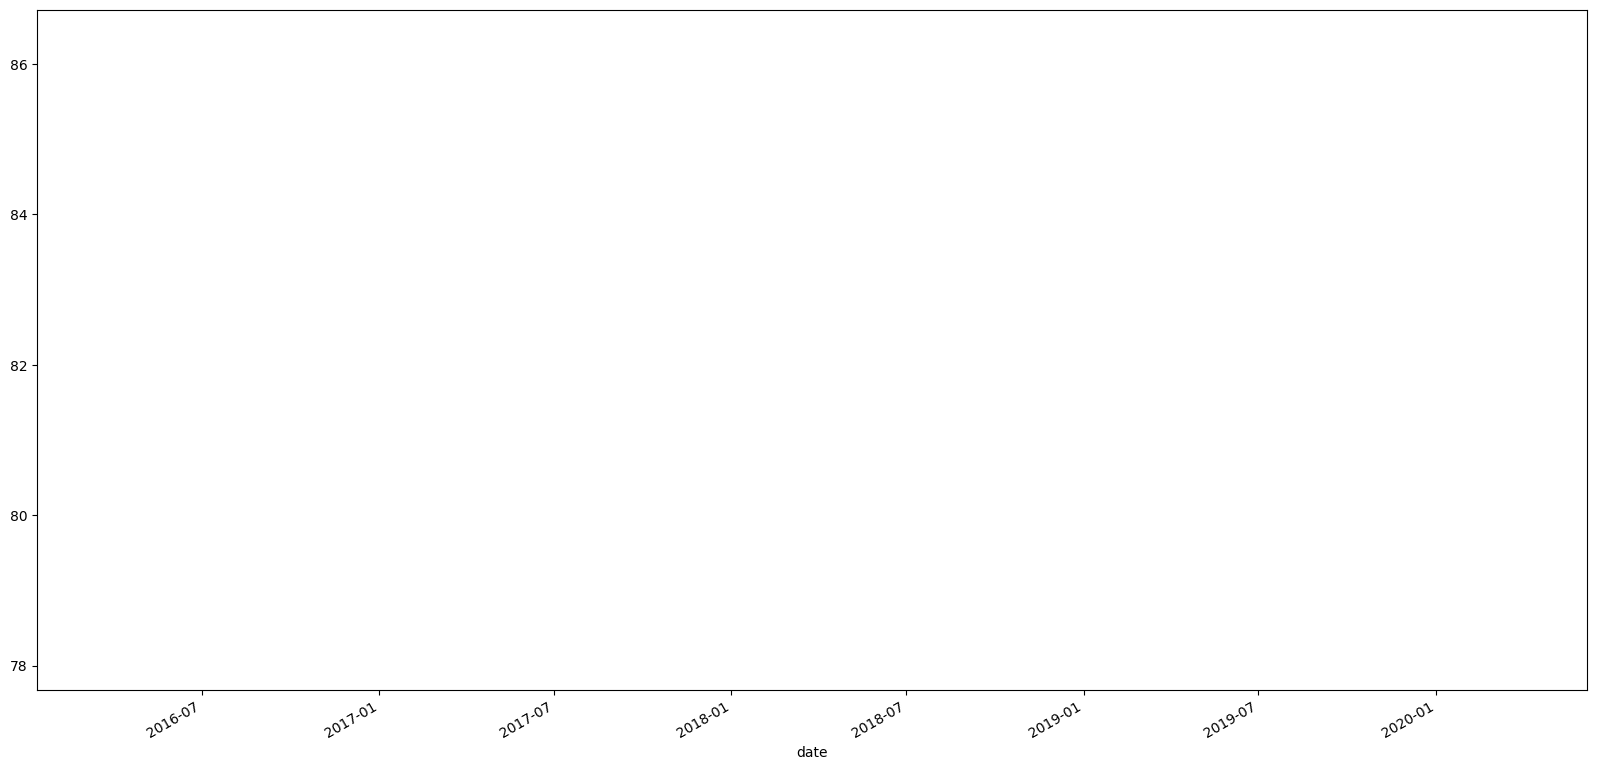

In [6]:
%matplotlib inline
import matplotlib.pyplot as plt
from talib import abstract

# 畫出均線
abstract.SMA(df).plot()

# 畫出收盤價
df['close'].plot()

RSI([input_arrays], [timeperiod=14])

Relative Strength Index (Momentum Indicators)

Inputs:
    price: (any ndarray)
Parameters:
    timeperiod: 14
Outputs:
    real


<Axes: xlabel='date'>

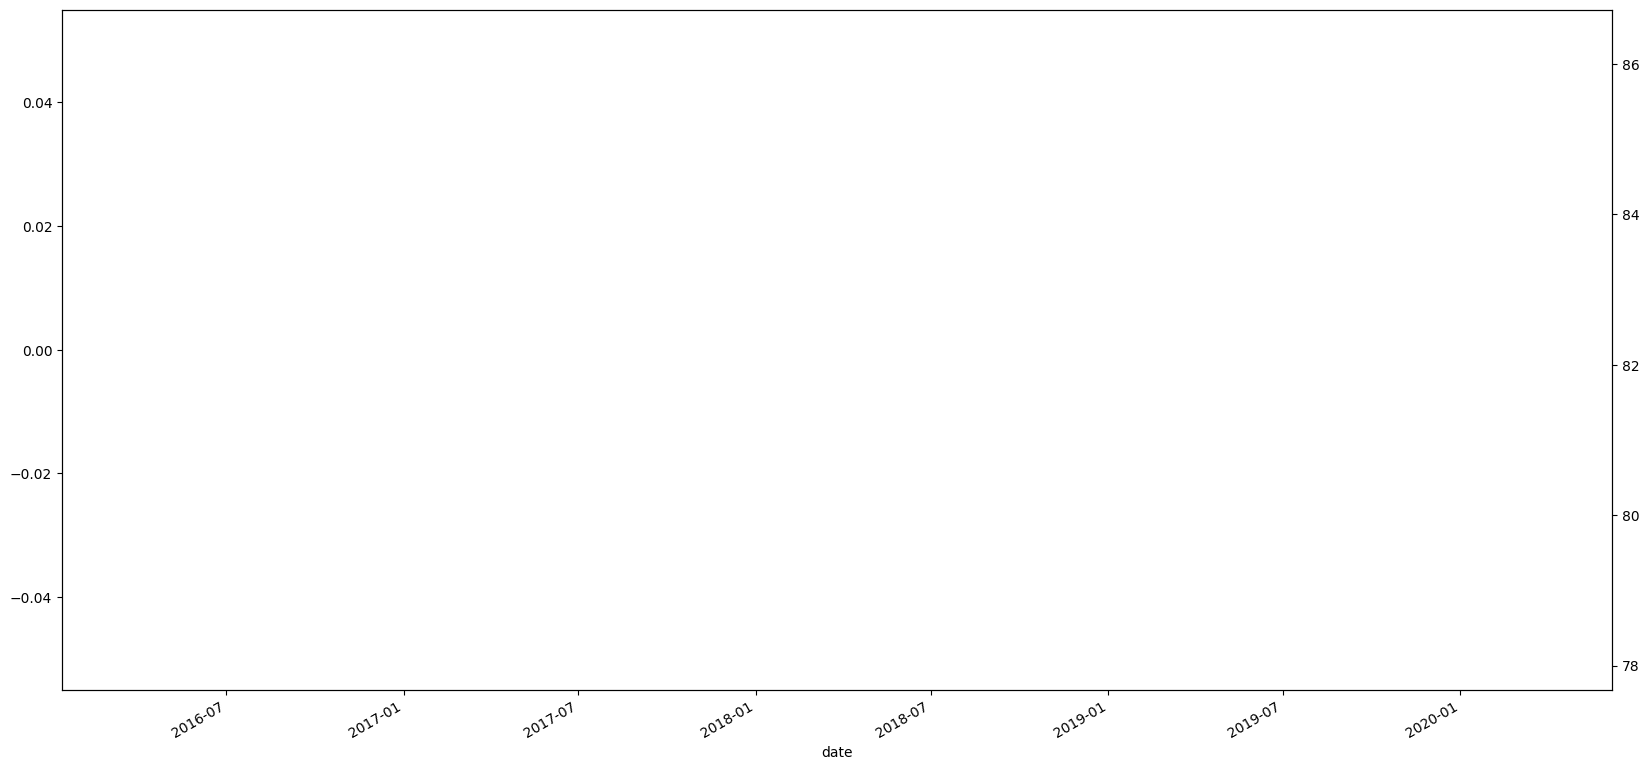

In [7]:
print(abstract.RSI)

# 畫出收盤價 並且將收盤價的y軸在右方
df['close'].plot(secondary_y=True)

# 讓 RSI 的y軸在左方
abstract.RSI(df, timeperiod=30).plot()

In [11]:
print(abstract.STOCH(df))

Exception: TA_STOCH function failed with error code 2: Bad Parameter (TA_BAD_PARAM)

In [13]:
from talib import abstract

# 創建各種指標
SMA = abstract.SMA(df)  # 平均線
RSI = abstract.RSI(df)
STOCH = abstract.STOCH(
    df.high, df.low, df.close, fastk_period=9, slowk_period=9, slowd_period=9
)  # KD值 [9, 9]  # KD值


from finlab.plot_candles import plot_candles

plot_candles(
    # 起始時間、結束時間
    start_time='2013-09-02',
    end_time='2013-12-31',
    # 股票的資料
    pricing=df,
    title='Candles',
    # 是否畫出成交量？
    volume_bars=True,
    # 將某些指標（如SMA）跟 K 線圖畫在一起
    overlays=[SMA],
    # 將某些指標（如RSI, STOCH）單獨畫在獨立的畫格中
    technicals=[RSI, STOCH],
    # 重新命名額外的畫格名稱（跟指標名稱一樣就可以囉！）
    technicals_titles=['RSI', 'KD'],
)

Exception: TA_STOCH function failed with error code 2: Bad Parameter (TA_BAD_PARAM)